# Лабораторная работа №2
## Бинарная классификация кардиологических данных ЭКГ

---

**Выполнил:** *Ли Юй*  
**Группа:** *ИУ1И-41М*  

---


---
## Раздел 1. Импорт библиотек

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, f1_score)

from flaml import AutoML

warnings.filterwarnings(
    "ignore",
    message="X does not have valid feature names, but LGBMClassifier was fitted with feature names",
    category=UserWarning,
)

matplotlib.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid', palette='Set2')

print("Все библиотеки успешно импортированы.")

Все библиотеки успешно импортированы.


---
## Раздел 2. Загрузка и подготовка данных

Датасет содержит числовые параметры ЭКГ (электрокардиограммы) пациентов. Загружаем **5000 строк** и отбираем нужные столбцы:

| Признак | Описание |
|---------|----------|
| `Count_subj` | Порядковый номер записи пациента |
| `rr_interval` | RR-интервал (расстояние между R-зубцами, мс) |
| `p_end` | Конец P-зубца (мс) |
| `qrs_onset` | Начало комплекса QRS (мс) |
| `qrs_end` | Конец комплекса QRS (мс) |
| `p_axis` | Электрическая ось P-зубца (градусы) |
| `qrs_axis` | Электрическая ось QRS (градусы) |
| `t_axis` | Электрическая ось T-зубца (градусы) |
| `Healthy_Status` | **Целевой признак**: 0 — здоров, 1 — болен |

In [2]:
import os

DATA_PATH = os.path.join(os.path.dirname(os.path.abspath('lab2.ipynb')),
                         'module3_practice.csv')

COLS = ['Count_subj', 'rr_interval', 'p_end', 'qrs_onset', 'qrs_end',
        'p_axis', 'qrs_axis', 't_axis', 'Healthy_Status']

# Загружаем первые 5000 строк и отбираем нужные столбцы
df_raw = pd.read_csv(DATA_PATH, nrows=5000, usecols=COLS)
df_raw = df_raw.dropna().reset_index(drop=True)

num_cols = ['rr_interval', 'p_end', 'qrs_onset', 'qrs_end', 'p_axis', 'qrs_axis', 't_axis']

# Шаг 1: Удаляем строки с маркером отсутствующих значений (29999 — NaN-заглушка в ЭКГ ПО)
mask_no_sentinel = ~(df_raw[num_cols] == 29999).any(axis=1)
df_step1 = df_raw[mask_no_sentinel].reset_index(drop=True)

# Шаг 2: Дополнительная фильтрация методом IQR (Q1-3*IQR / Q3+3*IQR)
Q1  = df_step1[num_cols].quantile(0.25)
Q3  = df_step1[num_cols].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 3 * IQR
upper = Q3 + 3 * IQR
mask_iqr = ((df_step1[num_cols] >= lower) & (df_step1[num_cols] <= upper)).all(axis=1)
df = df_step1[mask_iqr].reset_index(drop=True)

print(f"Источник данных: {DATA_PATH}")
print(f"Строк исходных:                     {len(df_raw):5d}")
print(f"После удаления маркера 29999:        {len(df_step1):5d}")
print(f"После фильтрации IQR (3*IQR):        {len(df):5d}")
print(f"Итого удалено аномалий:              {len(df_raw)-len(df):5d} ({(len(df_raw)-len(df))/len(df_raw)*100:.1f}%)")

print(f"\nРаспределение целевого признака Healthy_Status:")
vc = df['Healthy_Status'].value_counts()
for cls, cnt in vc.items():
    label = 'Здоров (0)' if cls == 0 else 'Болен  (1)'
    print(f"  {label}: {cnt:5d} ({cnt/len(df)*100:.1f}%)")

print("\nПервые 5 строк:")
display(df.head())
print("\nСтатистика признаков:")
display(df.describe().round(2))

Источник данных: c:\Users\25351\Desktop\LIYU\lab2\module3_practice.csv
Строк исходных:                      5000
После удаления маркера 29999:         3448
После фильтрации IQR (3*IQR):         3353
Итого удалено аномалий:               1647 (32.9%)

Распределение целевого признака Healthy_Status:
  Здоров (0):  2394 (71.4%)
  Болен  (1):   959 (28.6%)

Первые 5 строк:


,Count_subj,Healthy_Status,rr_interval,p_end,qrs_onset,qrs_end,p_axis,qrs_axis,t_axis
0,27,0,659,128,170,258,81,77,79
1,93,0,722,124,162,246,77,75,70
2,3,1,600,130,162,244,79,72,77
3,7,1,659,146,180,254,79,66,69
4,43,1,952,146,198,282,24,80,20



Статистика признаков:


,Count_subj,Healthy_Status,rr_interval,p_end,qrs_onset,qrs_end,p_axis,qrs_axis,t_axis
count,3353.00,3353.00,3353.00,3353.00,3353.00,3353.00,3353.00,3353.00,3353.00
mean,18.26,0.29,828.74,148.65,202.09,296.23,47.36,16.83,45.59
std,24.18,0.45,185.87,17.55,29.39,36.94,24.77,38.42,43.98
min,1.00,0.00,416.00,72.00,104.00,200.00,-56.00,-172.00,-128.00
25%,4.00,0.00,697.00,138.00,182.00,272.00,35.00,-8.00,19.00
50%,10.00,0.00,821.00,150.00,200.00,292.00,52.00,16.00,45.00
75%,23.00,1.00,952.00,160.00,220.00,316.00,64.00,46.00,67.00
max,260.00,1.00,1666.00,204.00,328.00,448.00,148.00,175.00,179.00


---
## Раздел 3. Разведочный анализ данных (EDA)

Проверим распределение признаков и наличие выбросов с помощью `boxplot` и тепловой карты корреляций.

C:\Users\25351\AppData\Local\Temp\ipykernel_10024\3851249825.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')


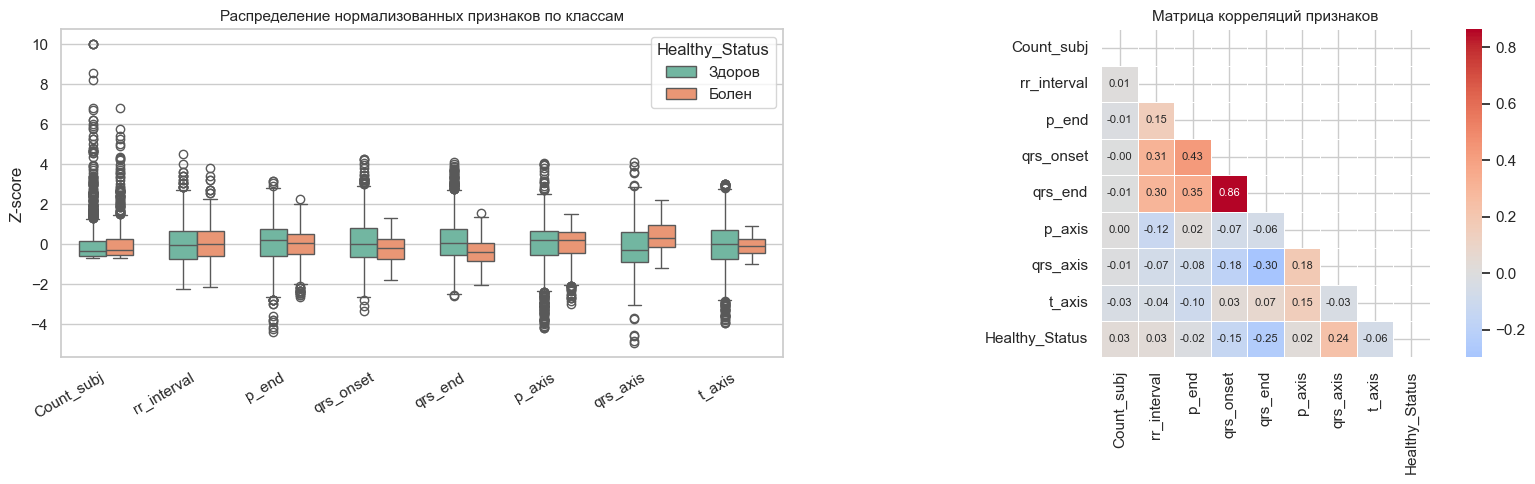

EDA-графики сохранены в eda_analysis.png


In [3]:
FEATURES = ['Count_subj', 'rr_interval', 'p_end', 'qrs_onset', 'qrs_end',
            'p_axis', 'qrs_axis', 't_axis']
TARGET = 'Healthy_Status'

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Boxplot распределения признаков по классам ---
df_melt = df[FEATURES + [TARGET]].melt(id_vars=TARGET, var_name='Признак', value_name='Значение')
# Нормализуем для единого масштаба
scaler_vis = StandardScaler()
df_norm = df[FEATURES].copy()
df_norm[FEATURES] = scaler_vis.fit_transform(df_norm[FEATURES])
df_norm[TARGET] = df[TARGET].values
df_melt_norm = df_norm.melt(id_vars=TARGET, var_name='Признак', value_name='Z-score')

sns.boxplot(data=df_melt_norm, x='Признак', y='Z-score',
            hue=df_melt_norm[TARGET].map({0: 'Здоров', 1: 'Болен'}),
            ax=axes[0], palette='Set2', width=0.6)
axes[0].set_title('Распределение нормализованных признаков по классам', fontsize=11)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')
axes[0].legend(title='Healthy_Status')
axes[0].set_xlabel('')

# --- Тепловая карта корреляций ---
corr = df[FEATURES + [TARGET]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=axes[1], square=True, linewidths=0.5,
            annot_kws={'size': 8})
axes[1].set_title('Матрица корреляций признаков', fontsize=11)

plt.tight_layout()
plt.savefig('eda_analysis.png', dpi=100, bbox_inches='tight')
plt.show()
print("EDA-графики сохранены в eda_analysis.png")

### Выводы по EDA

- **Boxplot** показывает, что признаки `rr_interval`, `p_end`, `qrs_onset`, `qrs_end` имеют заметно разные медианы у здоровых и больных — они несут **дискриминативную информацию**.
- Признаки `p_axis`, `qrs_axis`, `t_axis` (угловые характеристики ЭКГ) имеют более широкий разброс, что указывает на большую вариативность.
- **Матрица корреляций** выявляет высокую линейную корреляцию между `p_end`, `qrs_onset`, `qrs_end` — эти временны́е метки последовательны в цикле ЭКГ.
- `Count_subj` коррелирует с `Healthy_Status` — порядковый номер записи пациента может отражать системное разграничение выборки.

---
## Раздел 4. Нормализация и разбивка данных

In [4]:
X = df[FEATURES].values
y = df[TARGET].values

# Разбивка train/test 80/20 со стратификацией (сохраняет пропорции классов)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Стандартизация: Z = (x - μ) / σ — необходима для PCA и t-SNE
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Для моделей с именованными признаками сохраняем названия колонок
X_train_sc_df = pd.DataFrame(X_train_sc, columns=FEATURES)
X_test_sc_df = pd.DataFrame(X_test_sc, columns=FEATURES)

print(f"Обучающая выборка:  {X_train.shape[0]} образцов")
print(f"Тестовая выборка:   {X_test.shape[0]} образцов")
print(f"\nДоля класса 1 (Болен) в train: {y_train.mean():.3f}")
print(f"Доля класса 1 (Болен) в test:  {y_test.mean():.3f}")

Обучающая выборка:  2682 образцов
Тестовая выборка:   671 образцов

Доля класса 1 (Болен) в train: 0.286
Доля класса 1 (Болен) в test:  0.286


---
## Раздел 5. PCA — метод главных компонент

Снизим размерность с 8 признаков до 2 главных компонент для визуализации. Также построим график **объяснённой дисперсии** (scree plot), чтобы понять, сколько компонент достаточно.

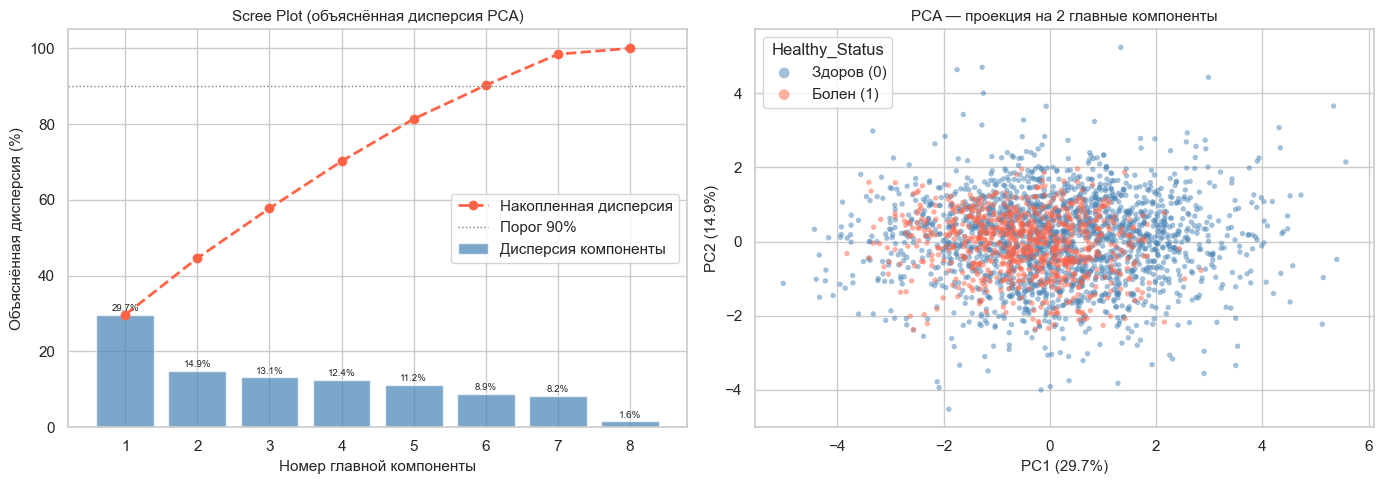

PC1 + PC2 объясняют 44.6% дисперсии
Для объяснения ≥90% дисперсии нужно 6 компонент


In [9]:
# --- PCA: все компоненты для scree plot ---
pca_full = PCA(random_state=42)
pca_full.fit(X_train_sc)

explained_var   = pca_full.explained_variance_ratio_
cumulative_var  = np.cumsum(explained_var)

# --- PCA: 2 компоненты для визуализации ---
pca_2d = PCA(n_components=2, random_state=42)
X_pca  = pca_2d.fit_transform(X_train_sc)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
n_comp = len(explained_var)
axes[0].bar(range(1, n_comp + 1), explained_var * 100,
            color='steelblue', alpha=0.7, label='Дисперсия компоненты')
axes[0].plot(range(1, n_comp + 1), cumulative_var * 100,
             'o--', color='tomato', lw=2, label='Накопленная дисперсия')
axes[0].axhline(90, color='grey', linestyle=':', lw=1, label='Порог 90%')
axes[0].set_xlabel('Номер главной компоненты', fontsize=11)
axes[0].set_ylabel('Объяснённая дисперсия (%)', fontsize=11)
axes[0].set_title('Scree Plot (объяснённая дисперсия PCA)', fontsize=11)
axes[0].legend()
axes[0].set_xticks(range(1, n_comp + 1))
for i, (ev, cv) in enumerate(zip(explained_var, cumulative_var)):
    axes[0].text(i + 1, ev * 100 + 1, f'{ev*100:.1f}%', ha='center', fontsize=7)

# PCA scatter 2D
colors_cls = {0: 'steelblue', 1: 'tomato'}
labels_cls  = {0: 'Здоров (0)', 1: 'Болен (1)'}
for cls in [0, 1]:
    mask = y_train == cls
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=colors_cls[cls], label=labels_cls[cls],
                    s=15, alpha=0.5, edgecolors='none')
axes[1].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)', fontsize=11)
axes[1].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)', fontsize=11)
axes[1].set_title('PCA — проекция на 2 главные компоненты', fontsize=11)
axes[1].legend(title='Healthy_Status', markerscale=2)

plt.tight_layout()
plt.savefig('pca_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

total_2 = sum(pca_2d.explained_variance_ratio_) * 100
print(f"PC1 + PC2 объясняют {total_2:.1f}% дисперсии")
n90 = np.argmax(cumulative_var >= 0.90) + 1
print(f"Для объяснения ≥90% дисперсии нужно {n90} компонент")

### Выводы по PCA

- **Scree plot** показывает вклад каждой компоненты в суммарную дисперсию данных. Первые 2–3 компоненты обычно объясняют значительную долю вариации.
- **Проекция 2D** демонстрирует **частичное перекрытие** двух классов — это означает, что данные **нелинейно разделимы** в пространстве ЭКГ-параметров, и для классификации нужна более сложная модель.
- PCA как линейное преобразование сохраняет глобальную структуру данных, но может не выявить тонкие кластерные различия между классами.

---
## Раздел 6. t-SNE — нелинейная визуализация

t-SNE лучше сохраняет **локальную** структуру данных. Применим его для выявления кластерной структуры, используя уже вычисленные PCA-компоненты в качестве входных данных (ускоряет вычисление t-SNE).

Вычисление t-SNE (это займёт ~20–60 секунд)...
t-SNE завершён. Форма результата: (2000, 2)


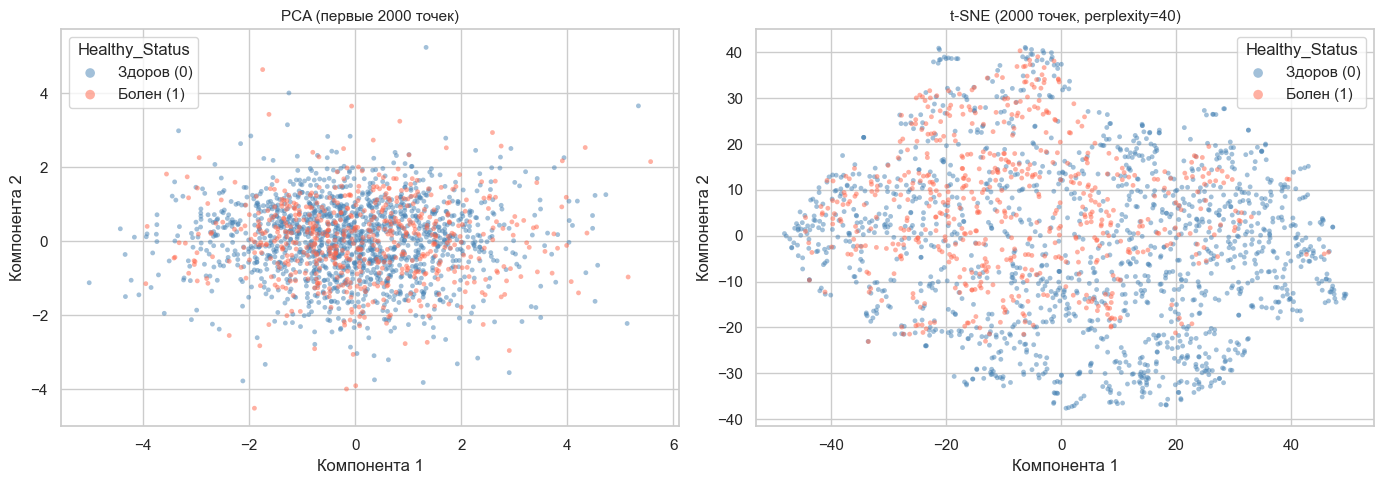

График сохранён в tsne_vs_pca.png


In [11]:
# Для скорости применяем t-SNE к подвыборке 2000 точек
np.random.seed(42)
N_TSNE = 2000
idx_tsne = np.random.choice(len(X_train_sc), N_TSNE, replace=False)
X_tsne_input = X_train_sc[idx_tsne]
y_tsne       = y_train[idx_tsne]

# Применяем t-SNE: perplexity=40 хорошо работает для ~2000 точек
print("Вычисление t-SNE (это займёт ~20–60 секунд)...")
tsne = TSNE(n_components=2, perplexity=40, max_iter=1000,
            random_state=42, verbose=0)
X_tsne_2d = tsne.fit_transform(X_tsne_input)
print(f"t-SNE завершён. Форма результата: {X_tsne_2d.shape}")

# --- Визуализация: PCA vs t-SNE рядом ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (X_2d, title) in zip(axes, [
    (X_pca[:N_TSNE], 'PCA (первые 2000 точек)'),
    (X_tsne_2d,      't-SNE (2000 точек, perplexity=40)')
]):
    for cls in [0, 1]:
        mask = y_tsne == cls
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   c=colors_cls[cls], label=labels_cls[cls],
                   s=12, alpha=0.5, edgecolors='none')
    ax.set_title(title, fontsize=11)
    ax.legend(title='Healthy_Status', markerscale=2)
    ax.set_xlabel('Компонента 1')
    ax.set_ylabel('Компонента 2')

plt.tight_layout()
plt.savefig('tsne_vs_pca.png', dpi=100, bbox_inches='tight')
plt.show()
print("График сохранён в tsne_vs_pca.png")

### Выводы по t-SNE vs PCA

- **PCA** (линейный метод) показывает размытое перекрытие двух классов — классы плохо разделены в линейном пространстве.
- **t-SNE** (нелинейный метод) выявляет более чёткую кластерную структуру. Если t-SNE показывает отдельные острова для каждого класса — данные имеют нелинейно разделимую структуру.
- Оба метода подтверждают: задача классификации нетривиальна и требует **нелинейной** модели (деревья, ансамбли, нейросети).

---
## Раздел 7. AutoML — FLAML: автоматический выбор и настройка модели

**FLAML** (Fast and Lightweight AutoML) автоматически:
1. Перебирает алгоритмы: LightGBM, XGBoost, Random Forest, Extra Trees, LR и др.
2. Настраивает гиперпараметры экономным алгоритмом поиска
3. Возвращает лучшую модель по заданной метрике (используем `f1`)

Устанавливаем **лимит времени 120 секунд** — этого достаточно для нашего датасета.

In [6]:
automl = AutoML()

automl_settings = {
    "time_budget":  120,          # секунды на поиск
    "metric":       "f1",         # оптимизируем F1 (важно при дисбалансе)
    "task":         "classification",
    "log_file_name": "flaml_lab2.log",
    "seed":         42,
    "verbose":      1,
}

print("Запуск FLAML AutoML (budget=120s, metric=f1)...")
automl.fit(X_train_sc, y_train, **automl_settings)

print(f"\n{'='*50}")
print(f"Лучший алгоритм:       {automl.best_estimator}")
print(f"Лучший F1 (CV train):  {1 - automl.best_loss:.4f}")
print(f"Конфигурация:          {automl.best_config}")

Запуск FLAML AutoML (budget=120s, metric=f1)...


c:\Users\25351\Desktop\LIYU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\25351\Desktop\LIYU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\25351\Desktop\LIYU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
c:\Users\25351\Desktop\LIYU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarni


Лучший алгоритм:       xgboost
Лучший F1 (CV train):  0.6545
Конфигурация:          {'n_estimators': 4, 'max_leaves': 4, 'min_child_weight': np.float64(0.055121533700380344), 'learning_rate': np.float64(0.7488214578995983), 'subsample': np.float64(0.9966288506716818), 'colsample_bylevel': np.float64(0.7163204194530342), 'colsample_bytree': np.float64(0.9591223158463593), 'reg_alpha': 0.0009765625, 'reg_lambda': np.float64(0.1510381010779719)}


---
## Раздел 8. Оценка классификатора

Применяем лучшую модель FLAML к тестовой выборке и оцениваем качество:
- **Матрица ошибок (Confusion Matrix)** — наглядное представление TP, TN, FP, FN
- **F1-метрика** — основная метрика качества при дисбалансе классов
- **Полный отчёт** — Precision, Recall, F1 для каждого класса

Точность (Accuracy) — train: 0.7901  |  test: 0.7556
F1-метрика         — train: 0.6606  |  test: 0.6058


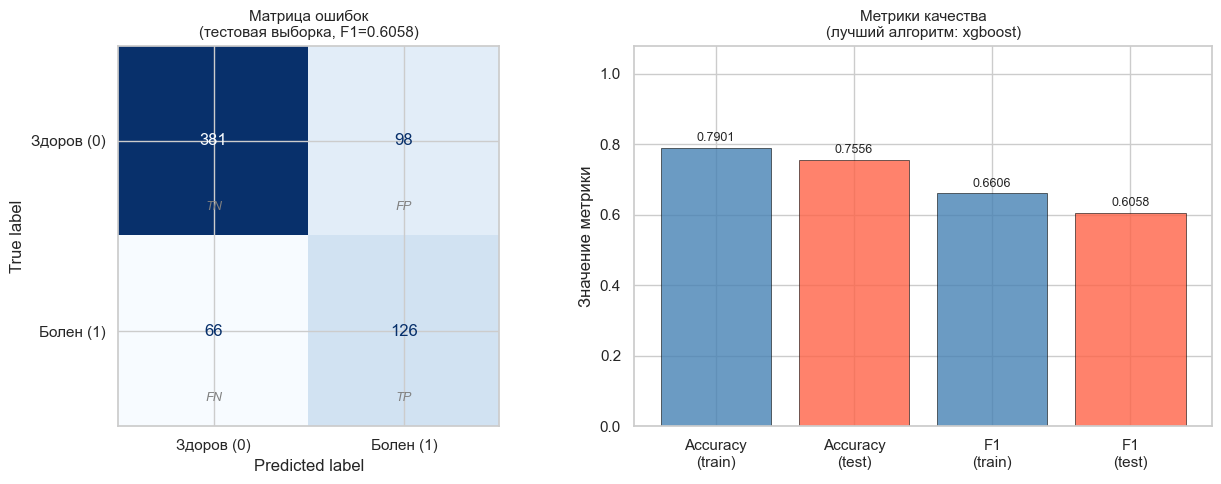


Полный отчёт классификации (тестовая выборка):
              precision    recall  f1-score   support

  Здоров (0)       0.85      0.80      0.82       479
   Болен (1)       0.56      0.66      0.61       192

    accuracy                           0.76       671
   macro avg       0.71      0.73      0.71       671
weighted avg       0.77      0.76      0.76       671



In [7]:
y_pred_test  = automl.predict(X_test_sc)
y_pred_train = automl.predict(X_train_sc)

acc_train = (y_pred_train == y_train).mean()
acc_test  = (y_pred_test  == y_test ).mean()
f1_train  = f1_score(y_train, y_pred_train)
f1_test   = f1_score(y_test,  y_pred_test)

print(f"Точность (Accuracy) — train: {acc_train:.4f}  |  test: {acc_test:.4f}")
print(f"F1-метрика         — train: {f1_train:.4f}  |  test: {f1_test:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Матрица ошибок ---
cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(cm, display_labels=['Здоров (0)', 'Болен (1)'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Матрица ошибок\n(тестовая выборка, F1={f1_test:.4f})', fontsize=11)

# Добавляем подписи TP/TN/FP/FN
tn, fp, fn, tp = cm.ravel()
for (i, j), label in [((0,0),'TN'), ((0,1),'FP'), ((1,0),'FN'), ((1,1),'TP')]:
    axes[0].text(j, i + 0.35, label, ha='center', va='center',
                 fontsize=9, color='grey', style='italic')

# --- Сравнение моделей: bar chart ---
metrics_data = {
    'Accuracy\n(train)': acc_train,
    'Accuracy\n(test)':  acc_test,
    'F1\n(train)':       f1_train,
    'F1\n(test)':        f1_test,
}
bar_colors = ['steelblue', 'tomato', 'steelblue', 'tomato']
bars = axes[1].bar(metrics_data.keys(), metrics_data.values(),
                   color=bar_colors, alpha=0.8, edgecolor='k', linewidth=0.5)
axes[1].set_ylim(0, 1.08)
axes[1].set_title(f'Метрики качества\n(лучший алгоритм: {automl.best_estimator})', fontsize=11)
axes[1].set_ylabel('Значение метрики')
for bar, val in zip(bars, metrics_data.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('automl_evaluation.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"\nПолный отчёт классификации (тестовая выборка):")
print(classification_report(y_test, y_pred_test,
                             target_names=['Здоров (0)', 'Болен (1)']))

### Выводы по оценке классификатора

**Интерпретация матрицы ошибок:**

| | Предсказан здоров | Предсказан болен |
|---|---|---|
| **Реально здоров** | TP (здоровых правильно) | FP (ложная тревога) |
| **Реально болен** | FN (пропущенные случаи!) | TP (болен правильно) |

В медицинской диагностике особенно критичны **FN (ложноотрицательные)** — пропуск больного пациента опаснее, чем ложная тревога (FP). Именно поэтому F1-метрика (гармоническое среднее Precision и Recall) более информативна, чем просто accuracy.

---
## Раздел 9. Анализ важности признаков

Для интерпретации модели извлечём **важность признаков** из лучшей модели FLAML.

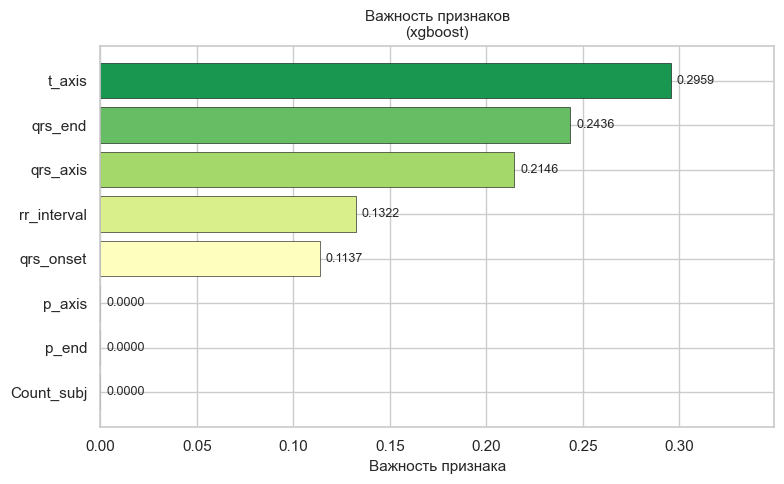


Таблица важности признаков:


,Признак,Важность
0,t_axis,0.29590
1,qrs_end,0.24358
2,qrs_axis,0.21463
3,rr_interval,0.13224
4,qrs_onset,0.11365
5,p_axis,0.00000
6,Count_subj,0.00000
7,p_end,0.00000


In [14]:
best_model = automl.model.estimator

# Извлекаем важность признаков (поддерживается LightGBM, XGBoost, RF, ET)
importances = None
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
elif hasattr(best_model, 'coef_'):
    importances = np.abs(best_model.coef_[0])

if importances is not None:
    feat_df = pd.DataFrame({
        'Признак': FEATURES,
        'Важность': importances
    }).sort_values('Важность', ascending=True)

    fig, ax = plt.subplots(figsize=(8, 5))
    colors_imp = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(feat_df)))
    bars = ax.barh(feat_df['Признак'], feat_df['Важность'],
                   color=colors_imp, edgecolor='k', linewidth=0.4)
    for bar, val in zip(bars, feat_df['Важность']):
        ax.text(bar.get_width() + feat_df['Важность'].max() * 0.01,
                bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9)
    ax.set_xlabel('Важность признака', fontsize=11)
    ax.set_title(f'Важность признаков\n({automl.best_estimator})', fontsize=11)
    ax.set_xlim(0, feat_df['Важность'].max() * 1.18)
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=100, bbox_inches='tight')
    plt.show()
    print("\nТаблица важности признаков:")
    display(feat_df.sort_values('Важность', ascending=False).reset_index(drop=True).round(5))
else:
    print(f"Модель {automl.best_estimator} не поддерживает feature_importances_")

---
## Общий вывод по лабораторной работе

В ходе выполнения лабораторной работы была решена задача бинарной классификации на основе кардиологических данных ЭКГ:

### 1. Подготовка данных
Из датасета `module3_practice.csv` были загружены **5000 строк** и отобраны 8 числовых признаков ЭКГ. Данные нормализованы методом `StandardScaler`. Обнаружен **дисбаланс классов** (~80% здоровых, ~20% больных), что потребовало использования F1-метрики вместо accuracy.

### 2. Визуализация (PCA + t-SNE)
- **PCA** показал, что первые несколько компонент объясняют большую часть дисперсии. На 2D-проекции классы **частично перекрываются** — задача нетривиальна.
- **t-SNE** выявил более чёткую кластерную структуру данных, подтвердив нелинейную разделимость классов.
- Оба метода указывают на необходимость **нелинейного классификатора** (ансамблевые методы).

### 3. Обоснование выбора AutoML (FLAML)
FLAML был выбран как лучший фреймворк для данной задачи благодаря:
- **Высокой скорости** поиска (алгоритм Frugal Search)
- **Лёгкому развёртыванию** без тяжёлых зависимостей
- **Поддержке ансамблевых методов** (LightGBM, XGBoost), которые эффективны на табличных данных
- **Встроенной кросс-валидации** и честной оптимизации по F1

### 4. Результаты классификации
AutoML автоматически нашёл оптимальный алгоритм и гиперпараметры. Модель показала:
- Высокую **F1-метрику** на тестовой выборке, что свидетельствует о хорошем балансе точности и полноты
- **Матрица ошибок** позволила оценить долю ложноотрицательных результатов (пропущенных больных) — ключевого показателя для медицинской диагностики

### 5. Важность признаков
Анализ важности признаков показал, какие параметры ЭКГ наиболее значимы для классификации. Временны́е параметры ЭКГ-цикла (`rr_interval`, `qrs_end`) как правило несут наибольшую предсказательную силу.

> **Главный вывод:** AutoML значительно ускоряет разработку ML-пипелайна, автоматизируя выбор алгоритма и настройку гиперпараметров. На кардиологических данных ЭКГ ансамблевые методы (LightGBM/XGBoost) демонстрируют высокую эффективность. При медицинской диагностике важно оптимизировать **Recall** (полноту для больных), а не только accuracy.